ahora lo que hare es ellavar el dt de numpy a pandas para "manipularlo"

In [2]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

import random

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


acarga del dt

In [4]:
df = np.load('dt_p/mnist.npz')

In [5]:
print("claves de npz", df.files)

claves de npz ['x_test', 'x_train', 'y_train', 'y_test']


In [6]:
df['x_train'].shape, df['y_train'].shape, df['x_test'].shape, df['y_test'].shape


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
# 2. Convertir X_train y X_test a DataFrames (aplanando a 784 columnas)
X_train_emnist = pd.DataFrame(df['x_train'].reshape(df['x_train'].shape[0], -1))
X_test_emnist  = pd.DataFrame(df['x_test'].reshape(df['x_test'].shape[0], -1))

y_train_emnist = pd.Series(df['y_train'], name='target')
y_test_emnist  = pd.Series(df['y_test'], name='target')

# Comprobar dimensiones
print("X_train (Pandas):", X_train_emnist.shape)
print("X_test (Pandas):", X_test_emnist.shape) 
print("y_train (Pandas):", y_train_emnist.shape) 
print("y_test (Pandas):", y_test_emnist.shape)   

X_train (Pandas): (60000, 784)
X_test (Pandas): (10000, 784)
y_train (Pandas): (60000,)
y_test (Pandas): (10000,)


In [8]:
print(X_train_emnist.head())

   0    1    2    3    4    5    6    7    8    9    ...  774  775  776  777  \
0    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   778  779  780  781  782  783  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 784 columns]


In [9]:
# 1. Obtener la lista de clases únicas (devuelve un arreglo con los valores)
clases_unicas = y_train_emnist.unique()

# 2. Obtener la cantidad total de clases
cantidad_clases = y_train_emnist.nunique()

print("Lista de clases únicas:", clases_unicas)
print("Cantidad total de clases:", cantidad_clases)

print("cantidad de img por clase en y_train:", y_train_emnist.value_counts())

Lista de clases únicas: [5 0 4 1 9 2 3 6 7 8]
Cantidad total de clases: 10
cantidad de img por clase en y_train: target
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64


In [10]:
X_train_emnist = X_train_emnist.to_numpy()
X_test_emnist = X_test_emnist.to_numpy()
y_train_emnist = y_train_emnist.to_numpy()
y_test_emnist = y_test_emnist.to_numpy()

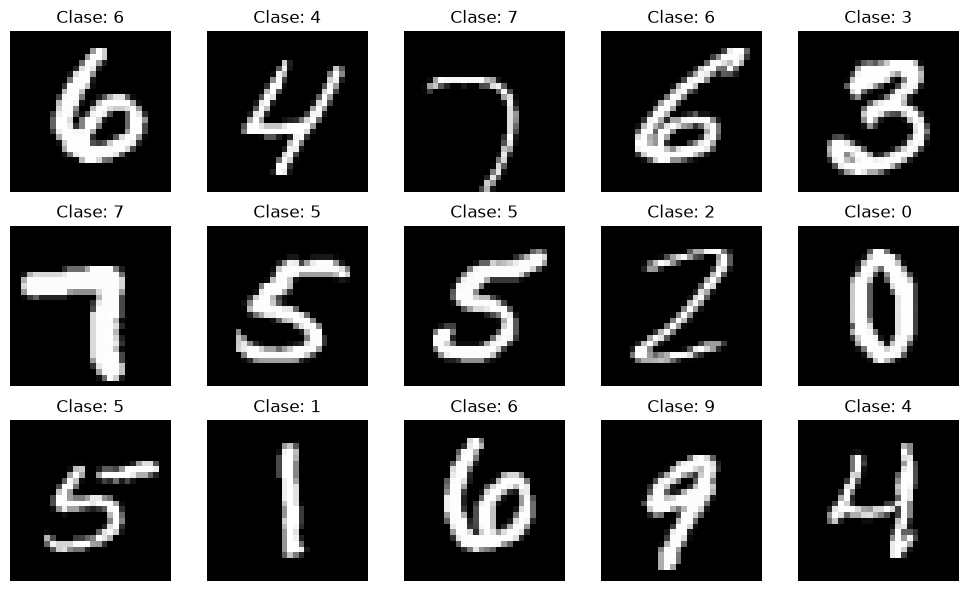

In [11]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_train_emnist) - 1)

        img = X_train_emnist[ix]

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")
        plt.title(f"Clase: {y_train_emnist[ix]}")

plt.tight_layout()
plt.show()

In [12]:
# Normalizamos los píxeles
X_train_emnist = X_train_emnist / 255.0
X_test_emnist = X_test_emnist / 255.0

# Convertimos las etiquetas a enteros
y_train_emnist = y_train_emnist.astype(np.int64)
y_test_emnist = y_test_emnist.astype(np.int64)

In [13]:
import torch

X_train_emnist_t = torch.tensor(
    X_train_emnist,
    dtype=torch.float32
).cuda()

X_test_emnist_t = torch.tensor(
    X_test_emnist,
    dtype=torch.float32
).cuda()

y_train_emnist_t = torch.tensor(
    y_train_emnist,
    dtype=torch.long
).cuda()

y_test_emnist_t = torch.tensor(
    y_test_emnist,
    dtype=torch.long
).cuda()

In [31]:
D_in, H1, D_out = 784, 100, 10
model_emnist = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, D_out),
).cuda()

criterion_emnist = torch.nn.CrossEntropyLoss()

optimizer_emnist = torch.optim.Adam(model_emnist.parameters(), lr=0.008)

epochs = 800
log_each = 10

l_emnist = []
val_l = []          # <<< NUEVO: guardamos la pérdida de validación por epoch

best_val_loss = float("inf")   # <<< NUEVO: mejor pérdida de validación vista hasta ahora
patience = 200                 # <<< NUEVO: epochs de tolerancia sin mejora antes de parar
step = 0                       # <<< NUEVO: contador de epochs sin mejora


model_emnist.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred_emnist = model_emnist(X_train_emnist_t)

    # Loss
    loss_emnist = criterion_emnist(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    # Ponemos a cero los gradientes
    optimizer_emnist.zero_grad()

    # Backpropagation
    loss_emnist.backward()

    # Actualizamos los pesos
    optimizer_emnist.step()


    # <<< NUEVO: bloque completo de validación + early stopping >>>
    model_emnist.eval()
    with torch.no_grad():
            val_logits = model_emnist(X_test_emnist_t)
            val_loss = criterion_emnist(
                val_logits,
                y_test_emnist_t
            )
    val_l.append(val_loss.item())
    
    if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            torch.save(model_emnist.state_dict(), "ckpt_preubita_npz.pt")
            step = 0
    else:
            step += 1
    
    if step > patience:
            print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
            break
        # <<< FIN bloque nuevo >>>


    if not e % log_each:
            print(
                f"Epoch {e}/{epochs} "
                f"Loss {loss_emnist.item():.5f} "
                f"Val_loss {val_loss.item():.5f}"     # <<< NUEVO en el print
            )
    
    model_emnist.load_state_dict(torch.load("ckpt_preubita_npz.pt"))

Epoch 10/800 Loss 0.45501 Val_loss 0.41819
Epoch 20/800 Loss 0.34207 Val_loss 0.33089
Epoch 30/800 Loss 0.28098 Val_loss 0.27434
Epoch 40/800 Loss 0.23465 Val_loss 0.23314
Epoch 50/800 Loss 0.19821 Val_loss 0.19990
Epoch 60/800 Loss 0.17038 Val_loss 0.17566
Epoch 70/800 Loss 0.14858 Val_loss 0.15849
Epoch 80/800 Loss 0.13112 Val_loss 0.14617
Epoch 90/800 Loss 0.11668 Val_loss 0.13665
Epoch 100/800 Loss 0.10450 Val_loss 0.12899
Epoch 110/800 Loss 0.09401 Val_loss 0.12279
Epoch 120/800 Loss 0.08475 Val_loss 0.11744
Epoch 130/800 Loss 0.07659 Val_loss 0.11325
Epoch 140/800 Loss 0.06939 Val_loss 0.11014
Epoch 150/800 Loss 0.06303 Val_loss 0.10740
Epoch 160/800 Loss 0.05741 Val_loss 0.10534
Epoch 170/800 Loss 0.05237 Val_loss 0.10412
Epoch 180/800 Loss 0.04784 Val_loss 0.10349
Epoch 190/800 Loss 0.04573 Val_loss 0.10372
Epoch 200/800 Loss 0.04573 Val_loss 0.10461
Epoch 210/800 Loss 0.04573 Val_loss 0.10510
Epoch 220/800 Loss 0.04573 Val_loss 0.10535
Epoch 230/800 Loss 0.04573 Val_loss 0.105

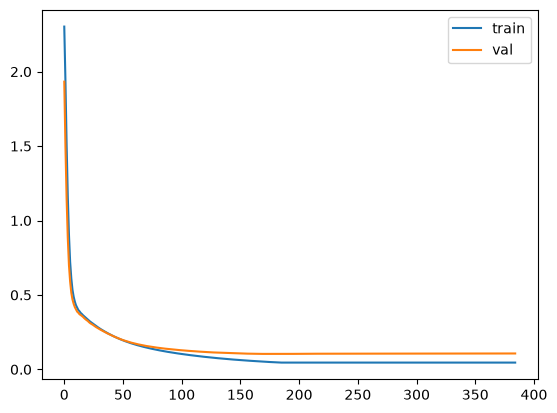

In [32]:
plt.plot(l_emnist, label="train")
plt.plot(val_l, label="val")
plt.legend()

In [33]:
from sklearn.metrics import accuracy_score

def evaluate_emnist(x):

    model_emnist.eval()

    # Forward
    logits = model_emnist(x)

    # Convertimos logits a probabilidades
    probabilidades = torch.softmax(logits, dim=1)

    # Elegimos la clase con mayor probabilidad
    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones


In [34]:
y_pred_emnist = evaluate_emnist(
    X_test_emnist_t
)

accuracy_emnist = accuracy_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 96.88%


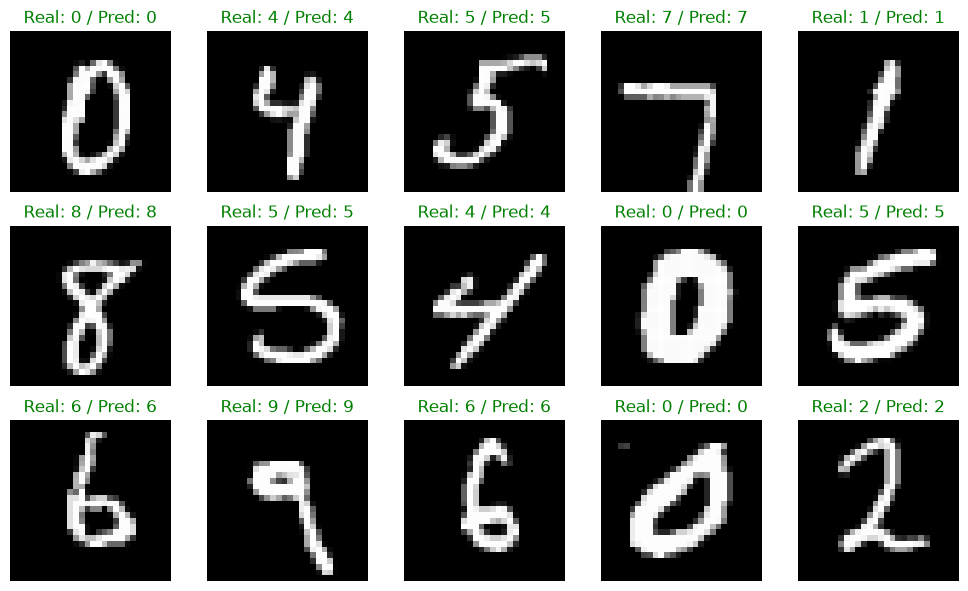

In [35]:
r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_test_emnist) - 1)

        img = X_test_emnist[ix]
        y_real = y_test_emnist[ix]

        # 1. Convertir a tensor y APLANAR a (1, 784)
        img_tensor = torch.tensor(img, dtype=torch.float32, device="cuda").reshape(1, -1)

        # 2. Evaluar
        y_pred = evaluate_emnist(img_tensor)[0].item()

        # 3. Graficar (asegurando que img sea 28x28 para plt.imshow)
        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(
            f"Real: {y_real} / Pred: {y_pred}",
            color="green" if y_real == y_pred else "red"
        )

plt.tight_layout()
plt.show()